파일을 로드합니다: /data1/mh/sionna/tutorials/rt/build code/paper/L1_data/vit_channel_dataset_precise_10s.npy
데이터 Shape: (20000, 8, 64, 72)


/tmp/ipykernel_39130/2467426922.py:33: RuntimeWarning: divide by zero encountered in log10
  avg_gain_over_time = 10 * np.log10(np.mean(power, axis=(2, 3)))


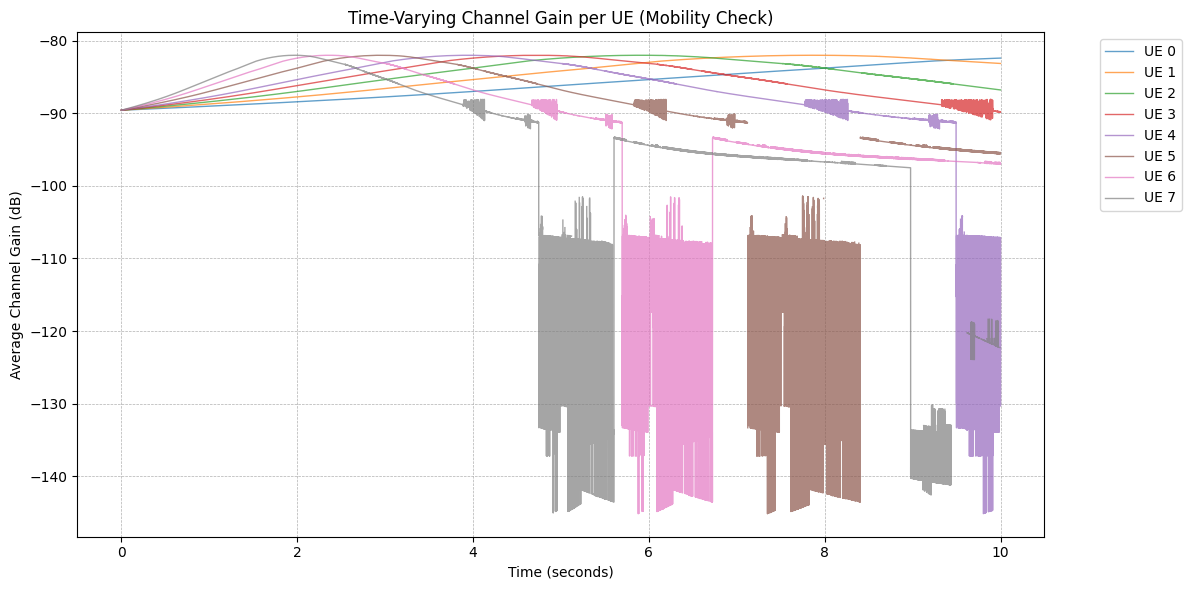

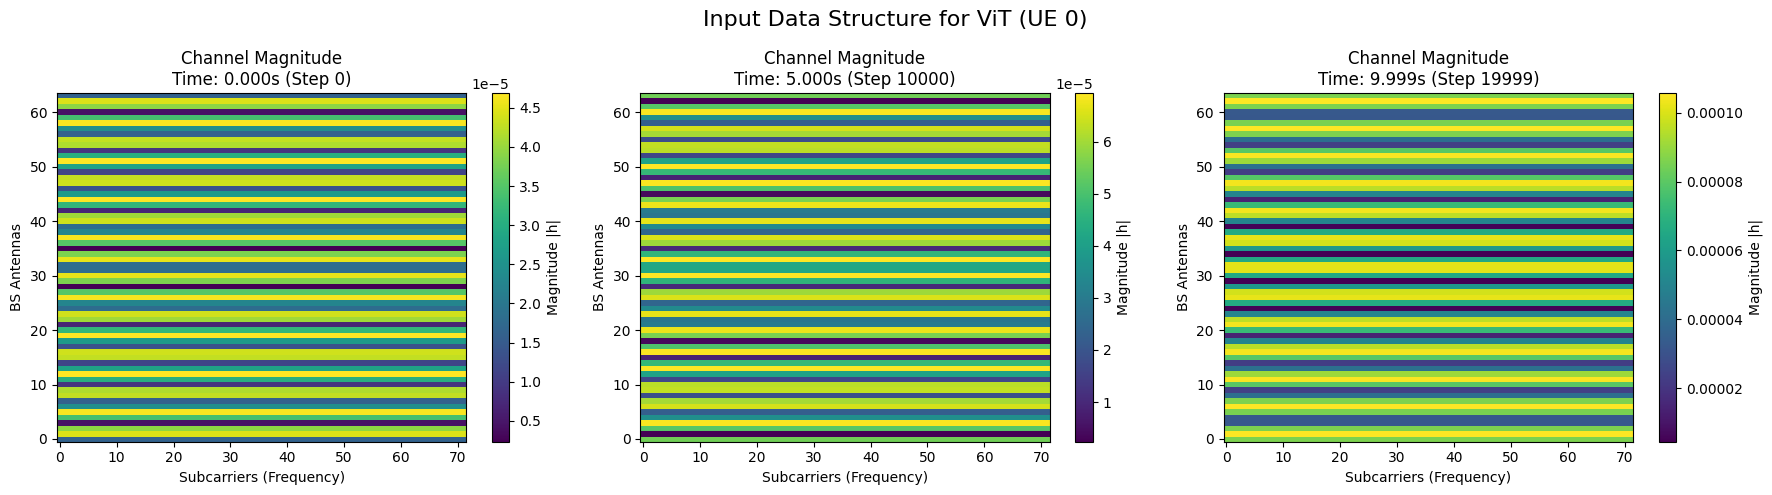

--------------------------------------------------
       [데이터 구조 상세 요약]       
--------------------------------------------------
1. 총 시뮬레이션 시간 : 10.0 초
2. 데이터 샘플링 간격 : 0.5 ms (1 Slot)
3. 총 데이터 샘플 수  : 20000 개
4. 사용자(UE) 수      : 8 명
5. ViT 입력 이미지 크기: 64 (H) x 72 (W)
--------------------------------------------------
해석 예시:
dataset_h[100, 2, :, :] -> 100번째 스텝(0.05초)에서
                           'UE_2'가 겪는 채널 이미지
--------------------------------------------------


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 데이터 준비 (메모리에 없으면 로드)
# ==========================================
# 만약 방금 생성한 dataset_h가 메모리에 있다면 이 부분은 건너뛰어도 됩니다.
if 'dataset_h' not in globals():
    try:
        # 경로를 본인의 환경에 맞게 수정하세요
        file_path = "/data1/mh/sionna/tutorials/rt/build code/paper/L1_data/vit_channel_dataset_precise_10s.npy"
        print(f"파일을 로드합니다: {file_path}")
        dataset_h = np.load(file_path)
    except FileNotFoundError:
        print("데이터 파일을 찾을 수 없습니다. dataset_h 변수가 메모리에 있는지 확인해주세요.")

# 데이터 형태 확인
# 예상 Shape: (Time, UE, Tx_Ant, Freq) -> (20000, 8, 64, 72)
print(f"데이터 Shape: {dataset_h.shape}")
num_steps, num_ues, num_ants, num_freqs = dataset_h.shape

# ==========================================
# 2. 시간별 채널 이득(Gain) 변화 그래프
# ==========================================
# 목적: UE들이 이동함에 따라 신호 세기가 변하는 것을 확인
# 계산: 각 시간 스텝마다 (안테나, 주파수) 축의 평균 파워를 구함

# 파워 계산 (절댓값 제곱)
power = np.abs(dataset_h)**2

# [Time, UE] 형태로 평균내기 (안테나와 주파수 차원은 평균)
# 10 * log10 으로 dB 변환
avg_gain_over_time = 10 * np.log10(np.mean(power, axis=(2, 3)))

# 시간 축 생성 (0.5ms 간격)
dt = 0.5e-3 # 0.5ms
time_axis = np.arange(num_steps) * dt

plt.figure(figsize=(12, 6))

# 모든 UE에 대해 그리기 (너무 많으면 일부만)
for ue_idx in range(num_ues):
    plt.plot(time_axis, avg_gain_over_time[:, ue_idx], label=f'UE {ue_idx}', alpha=0.7, linewidth=1)

plt.title("Time-Varying Channel Gain per UE (Mobility Check)")
plt.xlabel("Time (seconds)")
plt.ylabel("Average Channel Gain (dB)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 3. 특정 시점의 데이터 구조 (히트맵)
# ==========================================
# 목적: ViT에 들어가는 '이미지'가 어떻게 생겼는지 확인
# X축: 주파수 (Subcarriers), Y축: 기지국 안테나 (Tx Antennas)

target_ue = 0 # 보고 싶은 UE 인덱스
time_snapshots = [0, num_steps // 2, num_steps - 1] # 시작, 중간, 끝

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, t_idx in enumerate(time_snapshots):
    # 해당 시점, 해당 UE의 데이터 (64, 72)
    # 복소수이므로 크기(Magnitude)만 시각화
    h_snapshot = np.abs(dataset_h[t_idx, target_ue, :, :])
    
    # 시각화
    im = axes[i].imshow(h_snapshot, aspect='auto', origin='lower', cmap='viridis')
    axes[i].set_title(f"Channel Magnitude\nTime: {t_idx * dt:.3f}s (Step {t_idx})")
    axes[i].set_xlabel("Subcarriers (Frequency)")
    axes[i].set_ylabel("BS Antennas")
    fig.colorbar(im, ax=axes[i], label='Magnitude |h|')

plt.suptitle(f"Input Data Structure for ViT (UE {target_ue})", fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================
# 4. 텍스트로 구조 확인
# ==========================================
print("-" * 50)
print("       [데이터 구조 상세 요약]       ")
print("-" * 50)
print(f"1. 총 시뮬레이션 시간 : {num_steps * dt} 초")
print(f"2. 데이터 샘플링 간격 : {dt * 1000} ms (1 Slot)")
print(f"3. 총 데이터 샘플 수  : {num_steps} 개")
print(f"4. 사용자(UE) 수      : {num_ues} 명")
print(f"5. ViT 입력 이미지 크기: {num_ants} (H) x {num_freqs} (W)")
print("-" * 50)
print("해석 예시:")
print(f"dataset_h[100, 2, :, :] -> 100번째 스텝({100*dt}초)에서")
print(f"                           'UE_2'가 겪는 채널 이미지")
print("-" * 50)

Original Shape: (20000, 8, 64, 72)
Processed Shape (Freq Averaged): (20000, 8, 64)


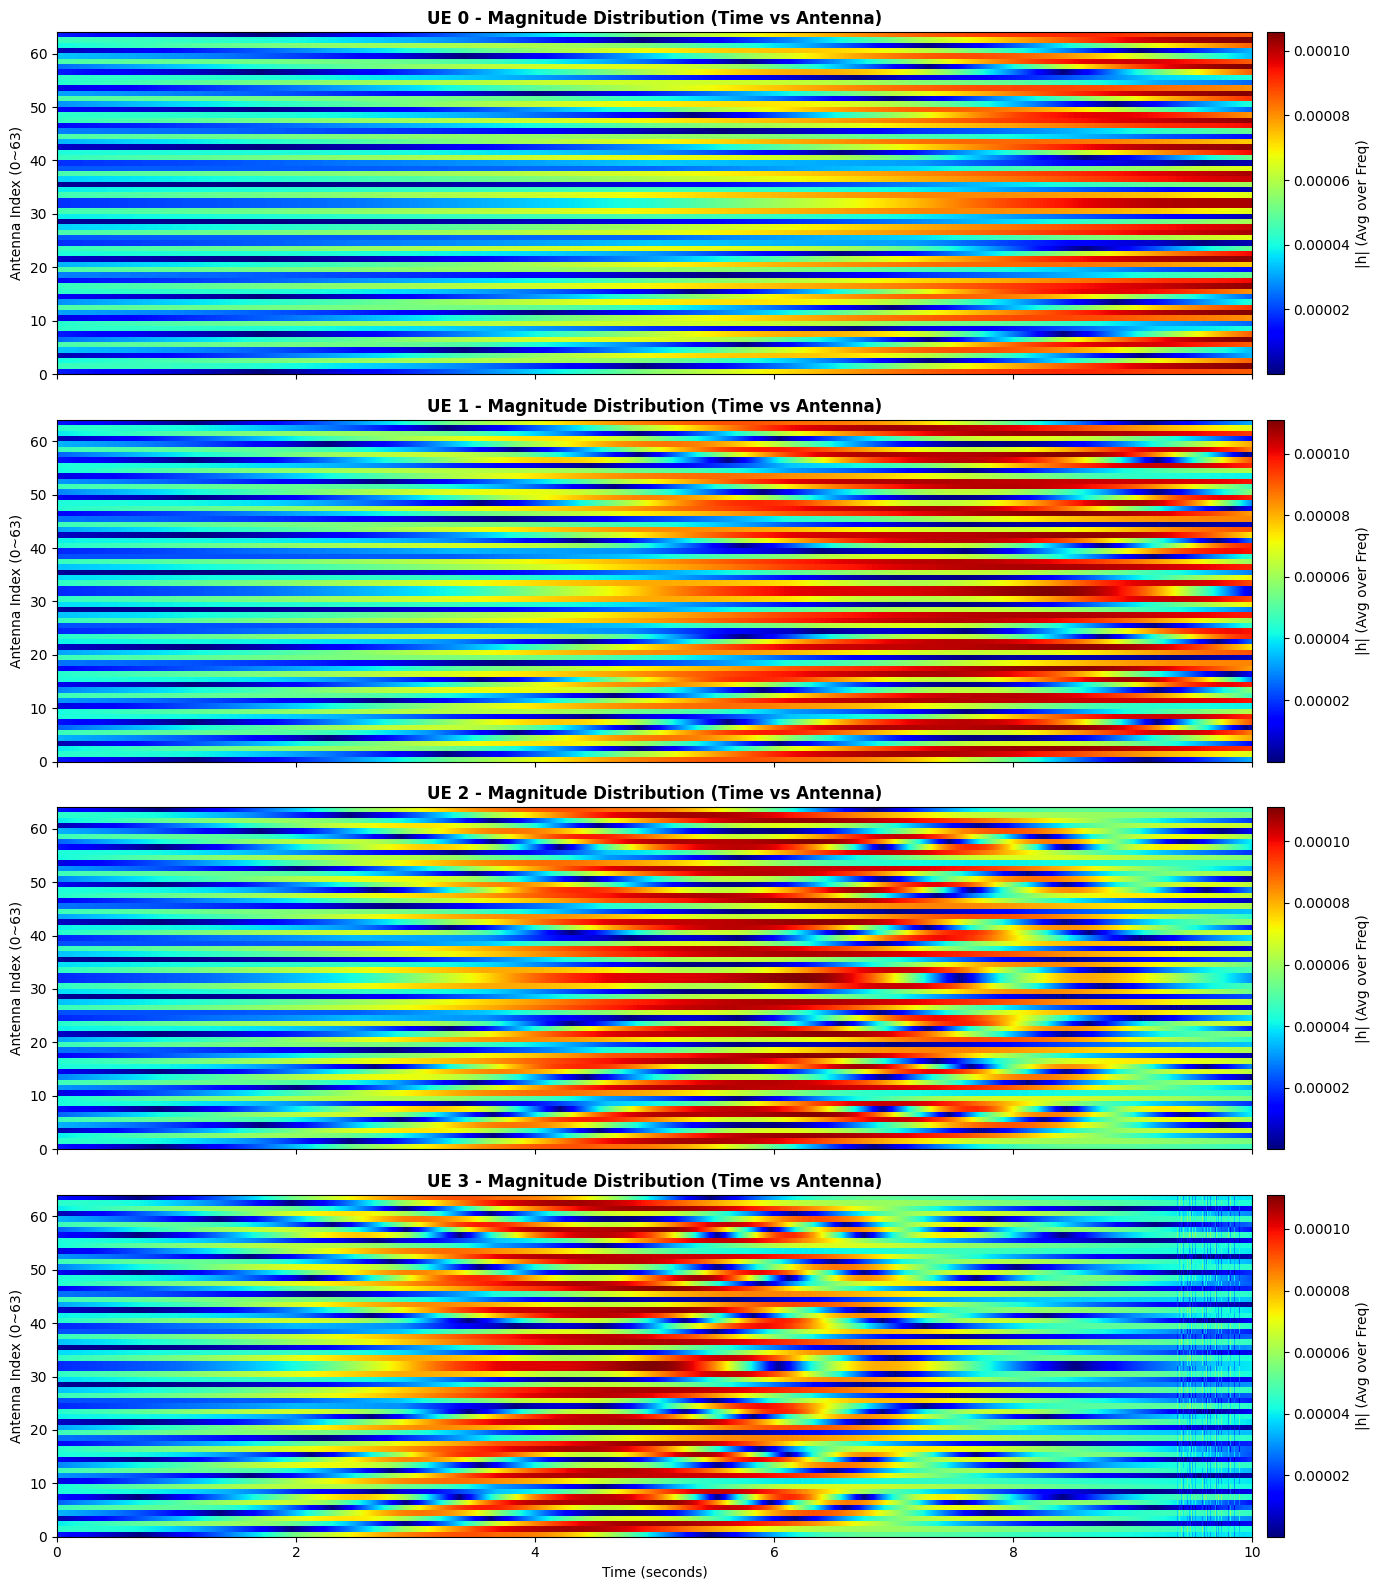

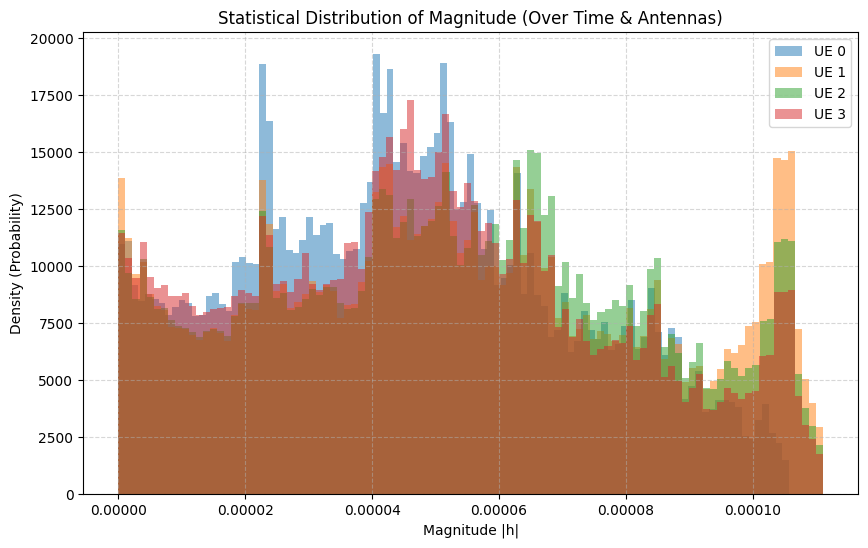

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. 데이터 로드
# ==========================================
# 파일 경로 (사용자 환경에 맞게 수정 필요)
file_path = "/data1/mh/sionna/tutorials/rt/build code/paper/L1_data/vit_channel_dataset_precise_10s.npy"

if 'dataset_h' not in globals():
    if os.path.exists(file_path):
        print(f"데이터를 로드합니다: {file_path}")
        dataset_h = np.load(file_path)
    else:
        print("[주의] 파일을 찾을 수 없습니다. dataset_h가 메모리에 있는지 확인하세요.")
        # 테스트용 더미 데이터 생성 (코드가 돌아가도록)
        # dataset_h = np.random.randn(20000, 8, 64, 72) + 1j * np.random.randn(20000, 8, 64, 72)

# 데이터 Shape: (Time, UE, Ant, Freq)
# 예: (20000, 8, 64, 72)
print(f"Original Shape: {dataset_h.shape}")
num_steps, num_ues, num_ants, num_freqs = dataset_h.shape
dt = 0.5e-3 # 0.5ms

# ==========================================
# 2. 데이터 전처리 (Subcarrier 무시)
# ==========================================
# 주파수 축(axis=3)에 대해 평균을 내어 (Time, UE, Ant) 형태로 만듭니다.
# |h| (Magnitude)를 먼저 구하고 평균을 냅니다.
magnitude_data = np.abs(dataset_h)
avg_magnitude_time_ant = np.mean(magnitude_data, axis=3) # Shape: (Time, UE, Ant)

print(f"Processed Shape (Freq Averaged): {avg_magnitude_time_ant.shape}")

# ==========================================
# 3. 시각화: 시간 vs 안테나 히트맵 (Heatmap)
# ==========================================
# 모든 UE를 다 그리면 너무 많으니, 대표적으로 UE 0, 1, 2만 그립니다.
target_ues = [0, 1, 2, 3] # 보고 싶은 UE 인덱스 목록

fig, axes = plt.subplots(len(target_ues), 1, figsize=(15, 4 * len(target_ues)), sharex=True)

if len(target_ues) == 1:
    axes = [axes] # 루프 처리를 위해 리스트로 변환

for i, ue_idx in enumerate(target_ues):
    ax = axes[i]
    
    # 데이터 추출: (Time, Ant) -> Transpose -> (Ant, Time) 형태로 변환해야 imshow에 적합
    # Shape: (64, 20000)
    data_to_plot = avg_magnitude_time_ant[:, ue_idx, :].T 
    
    # 히트맵 그리기
    # aspect='auto'로 설정해야 가로(20000)와 세로(64) 비율이 깨지지 않고 꽉 차게 나옵니다.
    im = ax.imshow(data_to_plot, aspect='auto', origin='lower', 
                   extent=[0, num_steps * dt, 0, num_ants], # [x_min, x_max, y_min, y_max]
                   cmap='jet', interpolation='nearest')
    
    ax.set_title(f"UE {ue_idx} - Magnitude Distribution (Time vs Antenna)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Antenna Index (0~63)")
    
    # 컬러바 추가
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('|h| (Avg over Freq)')

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

# ==========================================
# 4. 추가 분석: 안테나별 신호 크기 분포 (Histogram)
# ==========================================
# 특정 UE의 전체 시간 동안의 신호 크기 분포를 봅니다.
# 이는 페이딩 특성(Rayleigh, Rician 등)을 확인하는 데 유용합니다.

plt.figure(figsize=(10, 6))

for ue_idx in target_ues:
    # 해당 UE의 모든 시간, 모든 안테나의 Magnitude 값 펼치기
    flat_data = avg_magnitude_time_ant[:, ue_idx, :].flatten()
    
    # 히스토그램 (밀도 그래프)
    # bins=100 정도로 잘게 쪼개서 분포 확인
    plt.hist(flat_data, bins=100, density=True, alpha=0.5, label=f'UE {ue_idx}')

plt.title("Statistical Distribution of Magnitude (Over Time & Antennas)")
plt.xlabel("Magnitude |h|")
plt.ylabel("Density (Probability)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

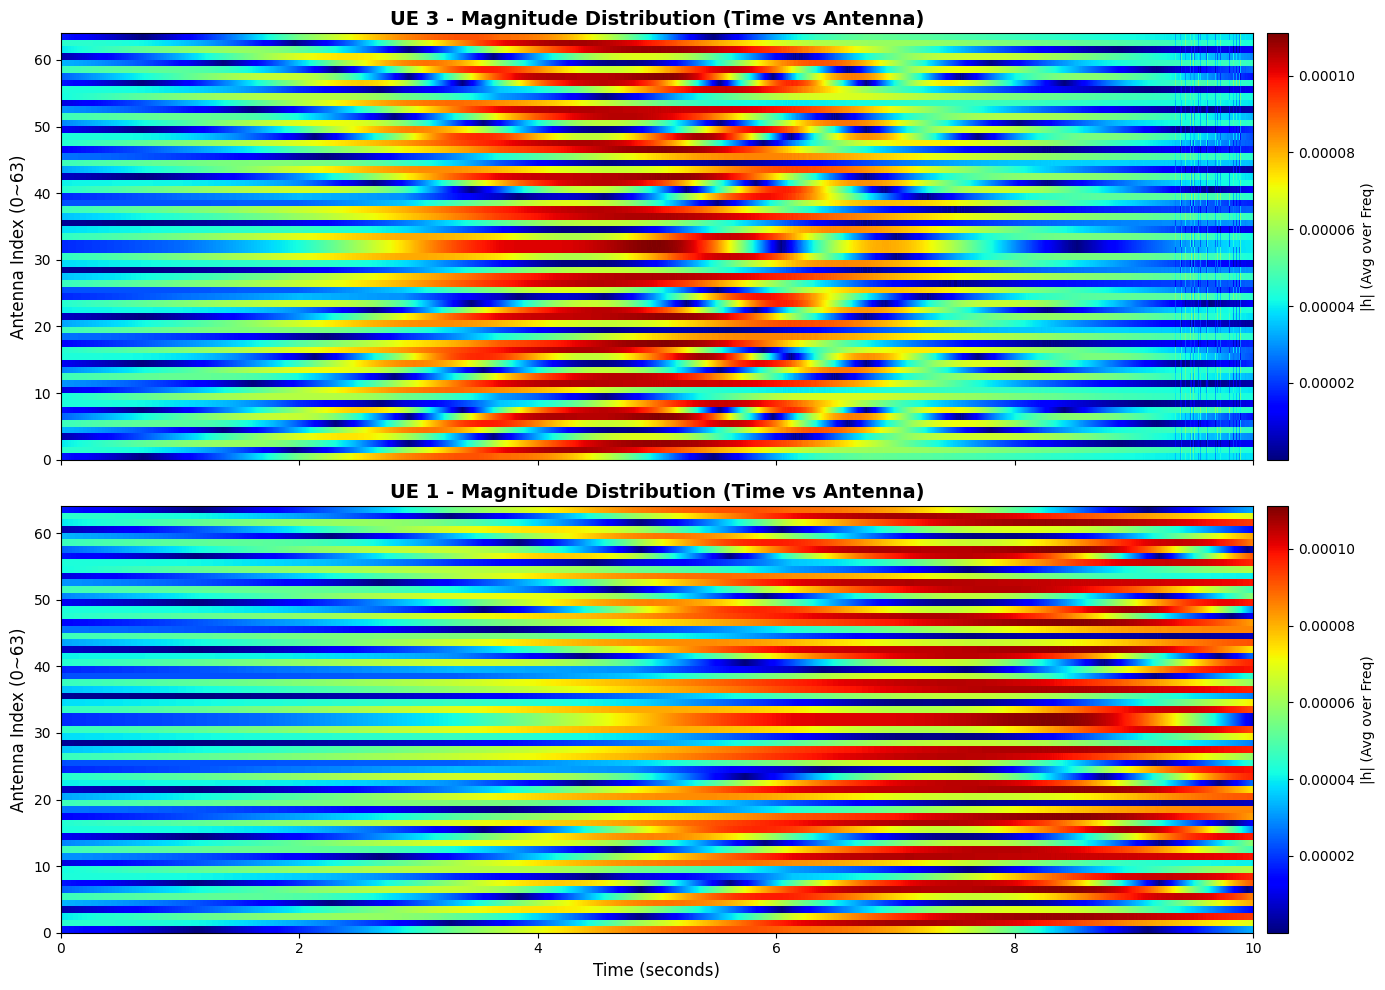

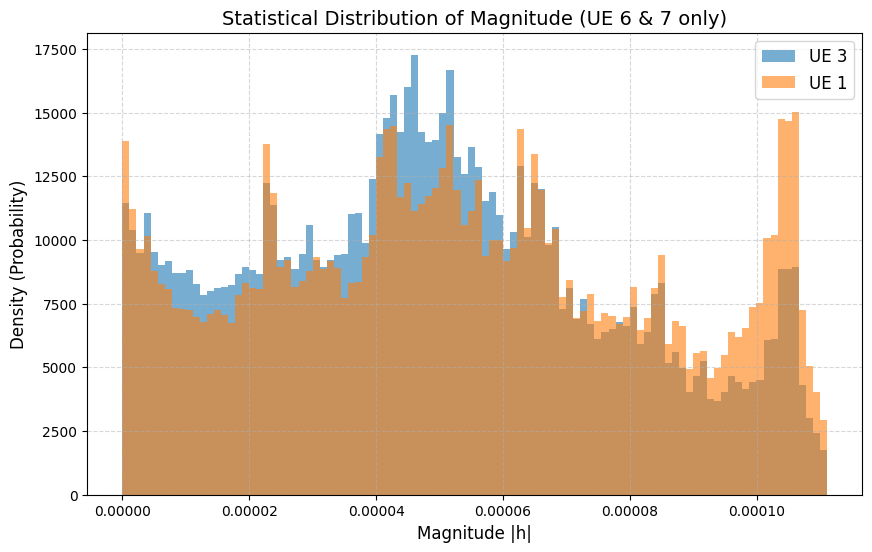

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. 데이터 로드
# ==========================================
# 파일 경로 (저장된 경로와 일치해야 합니다)
file_path = "/data1/mh/sionna/tutorials/rt/build code/paper/L1_data/vit_channel_dataset_precise_10s.npy"

if 'dataset_h' not in globals():
    if os.path.exists(file_path):
        print(f"데이터를 로드합니다: {file_path}")
        dataset_h = np.load(file_path)
    else:
        print("[주의] 파일을 찾을 수 없습니다. dataset_h가 메모리에 있는지 확인하세요.")
        # 파일이 없을 경우 테스트를 위한 임시 데이터 생성 (실제 사용 시 삭제 가능)
        # dataset_h = np.random.randn(20000, 8, 64, 72) + 1j * np.random.randn(20000, 8, 64, 72)

# 데이터 Shape 확인
# (Time, UE, Ant, Freq) -> 예: (20000, 8, 64, 72)
if 'dataset_h' in globals():
    num_steps, num_ues, num_ants, num_freqs = dataset_h.shape
    dt = 0.5e-3 # 0.5ms

    # ==========================================
    # 2. 데이터 전처리 (Subcarrier 무시)
    # ==========================================
    # 주파수 축(axis=3) 평균 -> (Time, UE, Ant)
    magnitude_data = np.abs(dataset_h)
    avg_magnitude_time_ant = np.mean(magnitude_data, axis=3)

    # ==========================================
    # 3. [수정됨] UE 6, 7에 대한 히트맵 시각화
    # ==========================================
    target_ues = [3, 1] # 여기를 6, 7로 변경했습니다.

    fig, axes = plt.subplots(len(target_ues), 1, figsize=(15, 5 * len(target_ues)), sharex=True)

    if len(target_ues) == 1:
        axes = [axes] # 루프 처리를 위해 리스트로 변환

    for i, ue_idx in enumerate(target_ues):
        ax = axes[i]
        
        # (Time, Ant) -> (Ant, Time)으로 전치(Transpose)하여 그리기
        data_to_plot = avg_magnitude_time_ant[:, ue_idx, :].T 
        
        # 히트맵 그리기
        im = ax.imshow(data_to_plot, aspect='auto', origin='lower', 
                       extent=[0, num_steps * dt, 0, num_ants], 
                       cmap='jet', interpolation='nearest')
        
        ax.set_title(f"UE {ue_idx} - Magnitude Distribution (Time vs Antenna)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Antenna Index (0~63)", fontsize=12)
        
        # 컬러바
        cbar = plt.colorbar(im, ax=ax, pad=0.01)
        cbar.set_label('|h| (Avg over Freq)', fontsize=10)

    axes[-1].set_xlabel("Time (seconds)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 4. [수정됨] UE 6, 7에 대한 히스토그램
    # ==========================================
    plt.figure(figsize=(10, 6))

    for ue_idx in target_ues:
        # 해당 UE의 모든 데이터 펼치기
        flat_data = avg_magnitude_time_ant[:, ue_idx, :].flatten()
        
        # 히스토그램 (밀도 그래프)
        plt.hist(flat_data, bins=100, density=True, alpha=0.6, label=f'UE {ue_idx}')

    plt.title("Statistical Distribution of Magnitude (UE 6 & 7 only)", fontsize=14)
    plt.xlabel("Magnitude |h|", fontsize=12)
    plt.ylabel("Density (Probability)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print("데이터가 로드되지 않아 시각화를 진행할 수 없습니다.")

In [3]:
import numpy as np

# 1. 저장된 파일 경로
file_path = "/data1/mh/sionna/tutorials/rt/build code/paper/L1_data/vit_channel_dataset_precise_10s.npy"

# 2. 데이터 로드
try:
    data = np.load(file_path)
    print("✅ 데이터를 성공적으로 로드했습니다.")
except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    data = None

if data is not None:
    # 3. 데이터 타입 확인 (가장 중요)
    print(f"\n1. 데이터 타입 (dtype): {data.dtype}")
    # 결과가 'complex64' 또는 'complex128'이면 실수+허수 모두 있는 것입니다.
    # 'float32'라면 실수만 있는 것입니다.

    # 4. 복소수 여부 판별 함수 사용
    if np.iscomplexobj(data):
        print("2. 결과: 이 데이터셋은 [복소수(Complex)] 데이터입니다. (실수부 + 허수부 포함)")
    else:
        print("2. 결과: 이 데이터셋은 [실수(Real)] 데이터입니다.")

    # 5. 실제 데이터 샘플 출력 (눈으로 확인)
    print("\n3. 데이터 샘플 확인 (첫 번째 값):")
    sample_value = data.flatten()[0] # 1차원으로 펴서 맨 첫 값만 확인
    print(f"   값: {sample_value}")
    
    # 실수부와 허수부 따로 찍어보기
    print(f"   - 실수부(Real): {sample_value.real}")
    print(f"   - 허수부(Imag): {sample_value.imag}")

    # 허수부가 0이 아닌지 체크
    if sample_value.imag != 0:
        print("\n   -> 확인: 허수부 데이터가 0이 아니므로 위상 정보가 포함되어 있습니다.")

✅ 데이터를 성공적으로 로드했습니다.

1. 데이터 타입 (dtype): float32
2. 결과: 이 데이터셋은 [실수(Real)] 데이터입니다.

3. 데이터 샘플 확인 (첫 번째 값):
   값: 1.6341564332833514e-05
   - 실수부(Real): 1.6341564332833514e-05
   - 허수부(Imag): 0.0


In [ ]:
import os
import tensorflow as tf
import numpy as np
import sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver

# -------------------------------------------------
# 1. 파일 저장 경로 및 이름 설정 (이름 변경 추천)
# -------------------------------------------------
output_dir = "/data1/mh/sionna/tutorials/rt/build code/paper/L1_data"
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 파일명을 변경하여 이전 파일과 섞이는 것을 방지합니다.
file_name = "vit_channel_dataset_precise_10s_complex.npy"
save_path = os.path.join(output_dir, file_name)

# -------------------------------------------------
# 2. 파라미터 및 맵 로드
# -------------------------------------------------
xml_path = "/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml"
scene_dir = os.path.dirname(xml_path)
temp_xml_path = os.path.join(scene_dir, "kookmin_fixed_absolute.xml")

carrier_frequency = 3.5e9
subcarrier_spacing = 30e3 
fft_size = 72
simulation_time = 1.0
dt = 0.5e-3
total_steps = int(simulation_time / dt)

# BS 위치
bs_position = [323.47, 36.87, -204.31]

# UE 이동성
num_ues = 8
speeds = [10/3.6, 15/3.6, 20/3.6, 25/3.6, 30/3.6, 40/3.6, 50/3.6, 60/3.6]

# road_positions 확인
if 'road_positions' not in globals():
    if os.path.exists("road_positions.npy"):
        road_positions = np.load("road_positions.npy")
    else:
        raise ValueError("road_positions 데이터가 없습니다.")

path_indices = [
    412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
    88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
    303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
    281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
    525, 582
]
trajectory_points = road_positions[path_indices]

class PolylineWalker:
    def __init__(self, points):
        self.points = points
        diffs = points[1:] - points[:-1]
        self.seg_lengths = np.linalg.norm(diffs, axis=1)
        self.cum_dist = np.insert(np.cumsum(self.seg_lengths), 0, 0.0)
        self.total_length = self.cum_dist[-1]
    def get_position(self, distance):
        if distance >= self.total_length: return self.points[-1]
        if distance <= 0: return self.points[0]
        idx = np.searchsorted(self.cum_dist, distance) - 1
        idx = max(0, idx)
        p_start = self.points[idx]
        p_end = self.points[idx+1]
        ratio = (distance - self.cum_dist[idx]) / self.seg_lengths[idx] if self.seg_lengths[idx] > 0 else 0
        return p_start + (p_end - p_start) * ratio

walker = PolylineWalker(trajectory_points)

# -------------------------------------------------
# 3. Scene 구성
# -------------------------------------------------
scene = load_scene(temp_xml_path)
bs_array = PlanarArray(num_rows=8, num_cols=8, vertical_spacing=0.5, horizontal_spacing=0.5, pattern="iso", polarization="V")
ue_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = bs_array
scene.rx_array = ue_array

scene.add(Transmitter(name="BS", position=bs_position, orientation=[0,0,0]))
ues = []
for i in range(num_ues):
    rx = Receiver(name=f"UE_{i}", position=trajectory_points[0], orientation=[0,0,0])
    scene.add(rx)
    ues.append(rx)

# -------------------------------------------------
# 4. 시뮬레이션 실행 (복소수 확인 추가)
# -------------------------------------------------
solver = PathSolver()
dataset_h = [] 

print(f"🚀 시뮬레이션 시작 (복소수 데이터 생성 중)...")

for step in range(total_steps):
    current_time = step * dt
    
    # 이동
    for i, ue in enumerate(ues):
        speed = speeds[i]
        new_pos = walker.get_position(speed * current_time)
        ue.position = new_pos
    
    # Ray Tracing
    paths = solver(scene, max_depth=3)
    
    # CFR 계산 (복소수)
    frequencies = subcarrier_spacing * tf.range(fft_size, dtype=tf.float32)
    cfr_output = paths.cfr(frequencies=frequencies)
    
    if isinstance(cfr_output, tuple): h_freq = cfr_output[0]
    else: h_freq = cfr_output
        
    # [확인용] 첫 번째 스텝에서만 데이터 타입 체크
    if step == 0:
        print(f"👉 생성된 텐서 타입: {h_freq.dtype}") # complex64 여야 함
        if not h_freq.dtype.is_complex:
            print("⚠️ 경고: 생성된 데이터가 복소수가 아닙니다!")

    dataset_h.append(h_freq.numpy())
    
    if step % 1000 == 0:
        print(f"Progress: {step}/{total_steps} ({(step/total_steps)*100:.1f}%)")

# -------------------------------------------------
# 5. 저장 (dtype=complex64 강제)
# -------------------------------------------------
print("데이터 변환 중...")
# [중요] dtype=np.complex64를 명시하여 실수형 변환을 막습니다.
dataset_h = np.array(dataset_h, dtype=np.complex64)
dataset_h = np.squeeze(dataset_h)

print(f"최종 데이터 형태: {dataset_h.shape}")
print(f"최종 데이터 타입: {dataset_h.dtype}") # complex64 확인

if np.iscomplexobj(dataset_h):
    print("✅ 확인: 복소수(Complex) 데이터가 정상적으로 생성되었습니다.")
else:
    print("❌ 오류: 여전히 실수(Real) 데이터입니다.")

np.save(save_path, dataset_h)
print(f"저장 완료: {save_path}")